# Optimized token demand across industry regimes

This notebook studies how physical token demand responds to token price $c$ and token efficiency $\eta$. Every point re-solves the user's choices:

- delegation horizon $s$ (human-hours of work between checkpoints),
- inference intensity $x$ (physical tokens per work-hour, per attempt), and
- retry cap $k$.

The user maximizes expected surplus—not token consumption. Adoption and aggregate token demand are downstream outcomes. The calibrations are illustrative and should not be read as estimates.

## Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from modeling_token_demand import (
    IndustryModel,
    OptimizationSettings,
    PolicyOptimizer,
    Scenario,
    illustrative_industries,
)

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
industries = illustrative_industries()

## What distinguishes the industries

The most important parameters are:

- $\lambda$: capability horizon. Larger values mean longer tasks remain inside the model's capability frontier.
- $a$: execution ease, conditional on the task being solvable.
- $\alpha$: diminishing returns to additional inference.
- $h_1$ and $\beta$: level and scaling of human verification effort. A $\beta$ near one means review grows almost proportionally with task size.
- $b$: value of one successfully completed hour-equivalent.
- $\mu$ and $\sigma$: location and dispersion of adoption hurdles. A small $\sigma$ places much of the industry's work near one sharp adoption threshold.

In [2]:
characteristics = {
    "Software development": (
        "Broad capability frontier, sublinear review, and adoption near the baseline."
    ),
    "High-review professional work": (
        "Verification is expensive and nearly linear in delegated scope (high h1 and beta)."
    ),
    "Routine automation": (
        "Easy execution, long feasible tasks, cheap verification, and nearly saturated adoption."
    ),
    "Capability-limited frontier work": (
        "Short capability horizon and difficult execution, offset by high-value output."
    ),
    "Near an adoption threshold": (
        "Software-like technology, but tightly clustered adoption hurdles (very small sigma)."
    ),
}

header = (
    "| Industry | lambda | a | alpha | h1 | beta | b | mu | sigma | Key characteristic |\n"
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|---|\n"
)
rows = []
for industry in industries:
    rows.append(
        f"| {industry.name} | {industry.capability_horizon_hours:g} | "
        f"{industry.execution_scale:g} | {industry.inference_returns:g} | "
        f"{industry.verification_scale:g} | "
        f"{industry.verification_elasticity:g} | "
        f"{industry.value_per_work_hour:g} | {industry.adoption_midpoint:g} | "
        f"{industry.adoption_scale:g} | {characteristics[industry.name]} |"
    )
display(Markdown(header + "\n".join(rows)))

| Industry | lambda | a | alpha | h1 | beta | b | mu | sigma | Key characteristic |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| Software development | 15 | 5 | 0.55 | 0.025 | 0.35 | 125 | 112 | 6 | Broad capability frontier, sublinear review, and adoption near the baseline. |
| High-review professional work | 12 | 4 | 0.5 | 0.13 | 0.95 | 125 | 100 | 7 | Verification is expensive and nearly linear in delegated scope (high h1 and beta). |
| Routine automation | 40 | 8 | 0.45 | 0.012 | 0.25 | 100 | 30 | 8 | Easy execution, long feasible tasks, cheap verification, and nearly saturated adoption. |
| Capability-limited frontier work | 2 | 1.5 | 0.6 | 0.08 | 0.5 | 220 | 152 | 10 | Short capability horizon and difficult execution, offset by high-value output. |
| Near an adoption threshold | 15 | 5 | 0.55 | 0.025 | 0.35 | 125 | 111.6 | 0.4 | Software-like technology, but tightly clustered adoption hurdles (very small sigma). |

## Numerical solution

The optimizer enumerates every integer retry cap and, conditional on each $k$, searches for the best $(s,x)$ in log space using a grid plus bounded multi-start local optimization. The action ranges below are intentionally wider than the ranges used in the original paper table. None of the plotted optima touches a continuous bound or the maximum retry cap.

In [3]:
settings = OptimizationSettings(
    min_delegation_hours=0.02,
    max_delegation_hours=80.0,
    min_tokens_per_work_hour=2_000.0,
    max_tokens_per_work_hour=2_000_000.0,
    max_attempts=12,
    grid_points_per_dimension=15,
    local_starts_per_attempt=3,
)
optimizer = PolicyOptimizer(settings)
baseline = Scenario()

In [4]:
def solve_axis(scenario_field, values):
    """Reoptimize every industry at every value on one scenario axis."""
    results = {}
    for industry in industries:
        model = IndustryModel(industry)
        results[industry.name] = [
            optimizer.solve(
                model, replace(baseline, **{scenario_field: float(value)})
            )
            for value in values
        ]
    return results


def plot_demand(values, results, xlabel, filename, baseline_value, reverse_x=False):
    """Plot demand and mark points where the optimal retry cap changes."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for industry_name, outcomes in results.items():
        demand = np.array([outcome.realized_tokens / 1e9 for outcome in outcomes])
        retries = np.array([outcome.policy.max_attempts for outcome in outcomes])
        style = {"linewidth": 3.0} if industry_name == "Near an adoption threshold" else {}
        line, = ax.plot(values, demand, label=industry_name, **style)
        switches = np.flatnonzero(retries[1:] != retries[:-1]) + 1
        ax.scatter(
            values[switches], demand[switches], color=line.get_color(),
            edgecolor="white", linewidth=0.7, s=38, zorder=4,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.axvline(baseline_value, color="0.35", linestyle="--", linewidth=1.2)
    if reverse_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Optimized physical token demand (billions per period)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def print_retry_switches(values, results):
    """Describe the discrete choices behind visible demand kinks."""
    for industry_name, outcomes in results.items():
        retries = np.array([outcome.policy.max_attempts for outcome in outcomes])
        switches = np.flatnonzero(retries[1:] != retries[:-1]) + 1
        if len(switches):
            descriptions = [
                f"{values[j - 1]:.3g} to {values[j]:.3g}: k {retries[j - 1]} to {retries[j]}"
                for j in switches
            ]
            print(f"{industry_name}: " + "; ".join(descriptions))

### Baseline optimized policies

In [5]:
baseline_rows = []
for industry in industries:
    outcome = optimizer.solve(IndustryModel(industry), baseline)
    baseline_rows.append(
        f"| {industry.name} | {outcome.policy.delegation_hours:.3f} | "
        f"{outcome.policy.tokens_per_work_hour:,.0f} | {outcome.policy.max_attempts} | "
        f"{outcome.eventual_success:.1%} | {outcome.adoption_share:.1%} | "
        f"{outcome.realized_tokens / 1e9:.1f} |"
    )
baseline_header = (
    "| Industry | s* (hours) | x* (tokens/hour) | k* | Success | Adoption | Demand (billions) |\n"
    "|---|---:|---:|---:|---:|---:|---:|\n"
)
display(Markdown(baseline_header + "\n".join(baseline_rows)))

| Industry | s* (hours) | x* (tokens/hour) | k* | Success | Adoption | Demand (billions) |
|---|---:|---:|---:|---:|---:|---:|
| Software development | 0.897 | 88,118 | 4 | 97.0% | 48.3% | 55.0 |
| High-review professional work | 0.465 | 115,150 | 3 | 97.5% | 45.5% | 60.6 |
| Routine automation | 1.385 | 33,010 | 6 | 98.9% | 100.0% | 45.5 |
| Capability-limited frontier work | 0.328 | 366,432 | 2 | 91.5% | 48.4% | 206.4 |
| Near an adoption threshold | 0.897 | 88,118 | 4 | 97.0% | 49.8% | 56.7 |

## Token price

The horizontal axis is reversed, so moving right means tokens become cheaper. The dashed line is the baseline price. Dots mark a change in the optimal retry cap.

Software development: 3.93 to 4.51: k 3 to 4; 26.7 to 30.7: k 4 to 5
High-review professional work: 2.99 to 3.43: k 2 to 3
Routine automation: 3.43 to 3.93: k 5 to 6; 13.5 to 15.5: k 6 to 7; 40.3 to 46.3: k 7 to 8
Capability-limited frontier work: 46.3 to 53: k 2 to 3
Near an adoption threshold: 3.93 to 4.51: k 3 to 4; 26.7 to 30.7: k 4 to 5


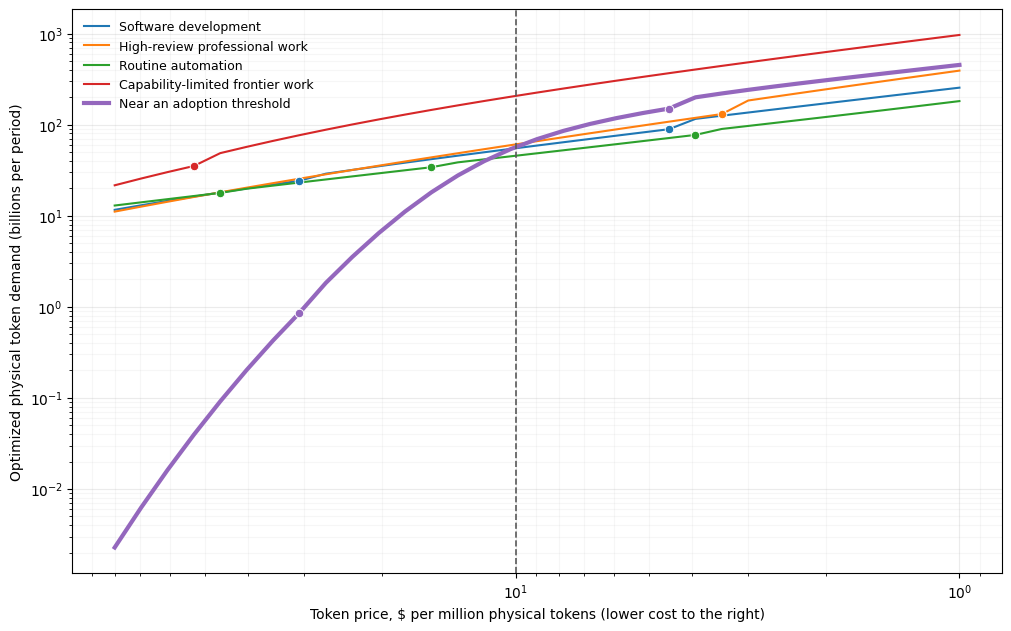

In [6]:
token_prices = np.geomspace(1.0, 80.0, 33)
price_results = solve_axis("token_price_per_million", token_prices)
print_retry_switches(token_prices, price_results)
price_figure = plot_demand(
    token_prices,
    price_results,
    xlabel="Token price, $ per million physical tokens (lower cost to the right)",
    filename="token-demand-vs-price.png",
    baseline_value=10.0,
    reverse_x=True,
)

Cheaper tokens increase optimized demand in these calibrations. The near-threshold regime responds especially sharply because lower cost raises optimized surplus enough to move a large share of work into adoption. This is a price response; the stricter Jevons-style efficiency experiment is below.

## Token efficiency

Higher $\eta$ means each physical token buys more effective inference while model capability $m$ is held fixed. Thus this experiment isolates efficiency from an outward shift in the capability frontier.

Software development: 0.35 to 0.38: k 5 to 4; 2.37 to 2.57: k 4 to 3
High-review professional work: 2.79 to 3.04: k 3 to 2
Routine automation: 0.68 to 0.739: k 7 to 6; 2.37 to 2.57: k 6 to 5
Near an adoption threshold: 0.35 to 0.38: k 5 to 4; 2.37 to 2.57: k 4 to 3


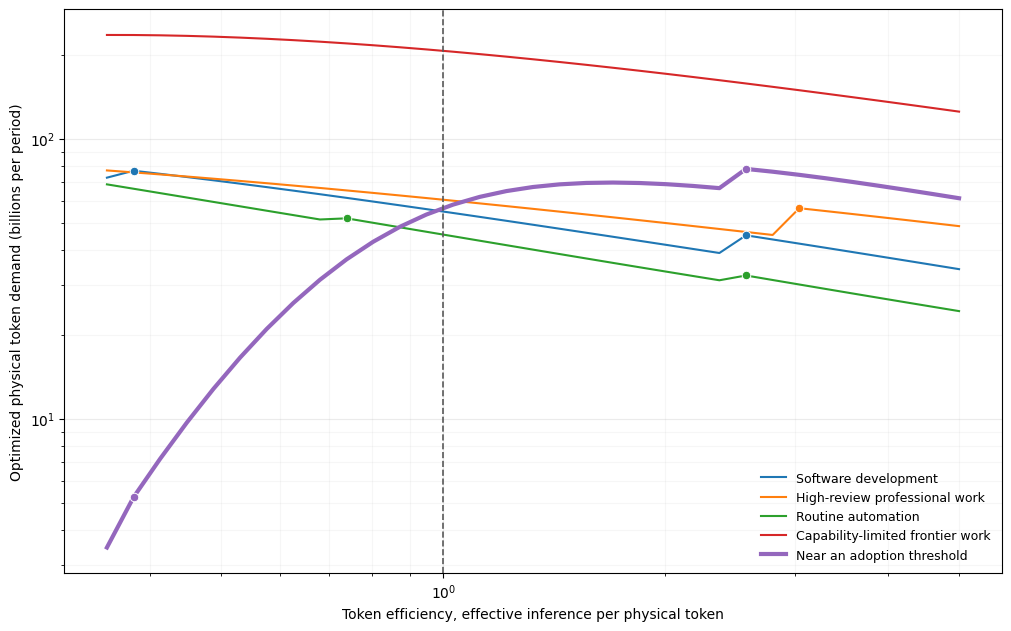

In [7]:
token_efficiencies = np.geomspace(0.35, 5.0, 33)
efficiency_results = solve_axis("token_efficiency", token_efficiencies)
print_retry_switches(token_efficiencies, efficiency_results)
efficiency_figure = plot_demand(
    token_efficiencies,
    efficiency_results,
    xlabel="Token efficiency, effective inference per physical token",
    filename="token-demand-vs-efficiency.png",
    baseline_value=1.0,
)

Most mature regimes are efficiency-dominated: users need fewer physical tokens per unit of work, while adoption does not expand enough to compensate. The purple near-threshold regime exhibits the Jevons-style case. Demand initially rises because a narrow mass of work crosses the adoption threshold, then falls after adoption approaches saturation.

The frontier-work line remains high but slopes downward here because the experiment improves execution efficiency without changing the solvable-task share $q$. Increasing model capability $m$ would move that capability frontier and produces different dynamics.

## Why some curves have kinks

For a fixed retry cap, the optimized surplus surface is smooth. The overall policy need not be smooth because $k$ is an integer. A kink or small jump in token demand can occur when the surplus-maximizing policy switches from one retry cap to another; token demand itself is not the user's objective and can jump even when the maximized surplus is nearly continuous.

The cell below shows the leading fixed-$k$ policies on opposite sides of one efficiency-driven switch.

In [8]:
software_model = IndustryModel(industries[0])
comparison_rows = []
for eta in (2.5, 2.8):
    by_attempts = optimizer.solve_by_attempts(
        software_model, replace(baseline, token_efficiency=eta)
    )
    ranked = sorted(
        by_attempts.values(), key=lambda item: item.surplus_per_work_hour, reverse=True
    )[:3]
    for rank, outcome in enumerate(ranked, start=1):
        comparison_rows.append(
            f"| {eta:g} | {rank} | {outcome.policy.max_attempts} | "
            f"{outcome.policy.delegation_hours:.3f} | "
            f"{outcome.policy.tokens_per_work_hour:,.0f} | "
            f"{outcome.surplus_per_work_hour:.6f} | "
            f"{outcome.realized_tokens / 1e9:.2f} |"
        )
comparison_header = (
    "| eta | Rank | k | s* | x* | Surplus/hour | Demand (billions) |\n"
    "|---:|---:|---:|---:|---:|---:|---:|\n"
)
display(Markdown(comparison_header + "\n".join(comparison_rows)))

| eta | Rank | k | s* | x* | Surplus/hour | Demand (billions) |
|---:|---:|---:|---:|---:|---:|---:|
| 2.5 | 1 | 4 | 0.935 | 59,087 | 112.441795 | 38.27 |
| 2.5 | 2 | 3 | 0.909 | 74,119 | 112.440561 | 45.77 |
| 2.5 | 3 | 5 | 0.937 | 54,331 | 112.270156 | 35.81 |
| 2.8 | 1 | 3 | 0.914 | 70,413 | 112.537972 | 43.70 |
| 2.8 | 2 | 4 | 0.938 | 56,298 | 112.523302 | 36.56 |
| 2.8 | 3 | 5 | 0.939 | 51,956 | 112.347613 | 34.31 |

### Optimizer audit

As a separate validation, all plotted retry-switch neighborhoods and representative interior points were compared against SciPy's independent differential-evolution global optimizer. Across 42 industry/scenario cases, the largest surplus difference was $2.1\times10^{-12}$ dollars per work-hour and the selected retry cap agreed in every case. A wider search allowing up to 20 retries selected at most eight. This does not constitute a formal proof of global optimality, but it is strong numerical evidence that the visible kinks are genuine discrete-policy switches rather than failed local searches.

All plots assume one million potential work-hours per industry and no binding aggregate human-attention cap. The attention-constrained equilibrium remains a separate extension.